# Copymint Baseline — Logistic Regression on Perceptual Hash Distances

**Goal:** fuse normalized hash distances (`aHash`, `pHash`, `dHash`, `HSVHash`) into a single duplicate-probability score using binary logistic regression.

**Pipeline:**
1. Load the pair-level dataset (`label=1` → derivative copy / matching pair, `label=0` → different image)
2. **Stratified 80/20 train–test split** (stratified on `label` so both splits keep the same positive rate)
3. Train on the 80% split, evaluate on the held-out 20% with **ROC-AUC** (primary), **PR-AUC**, **F1**, and **Recall @ 95% Precision** — never raw accuracy on imbalanced data
4. Inspect coefficients, error-analysis by transformation type, and pick an operating threshold
5. Refit on the full dataset and serialize the model for the minting gate

> **Dataset:** scaled to the DISC21-derived set (~2.2k pairs). Positives combine (a) synthetic augmentations of a few seed images (`cropped_*`, `blur_*`, `grayscale`, …) and (b) real DISC21 query↔reference matching pairs (`disc21`). Negatives are `cross_image` and `disc21_neg` pairs.
>
> ⚠️ **Negative-set caveat:** most `disc21_neg` rows pair queries against a single reference image (`R038409`). With a random split this leaks across train/test, so the model partly learns "distance-from-R038409" rather than a general non-match boundary. Treat the headline numbers as optimistic until the negative pool is diversified across many references.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CSV_PATH = "/content/combined_training_data.csv"   # <-- update to your DISC21 CSV path
FEATURES = ["ahash_dist", "phash_dist", "dhash_dist", "hsvhash_dist"]

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

## 1. Load & inspect the data

All hash distances are already **normalized by bit-length** (Hamming distance / number of bits), so features are on a comparable [0, 1] scale across algorithms of different lengths.

In [ ]:
df = pd.read_csv(CSV_PATH)

print(f"Pairs: {len(df)}")
print(f"Label balance: {df['label'].value_counts().to_dict()}  "
      f"(positive rate = {df['label'].mean():.2%})")
print(f"Transformation types: {df['transformation'].nunique()}")
df.head()

Pairs: 2223
Label balance: {0: 1140, 1: 1083}  (positive rate = 48.72%)
Transformation types: 21


,image_a,image_b,transformation,label,ahash_dist,phash_dist,dhash_dist,hsvhash_dist
0,images/dragon-bridge.png,images_variants/dragon-bridge/altered.png,altered_20%,1,0.0312,0.0159,0.0278,0.0476
1,images/dragon-bridge.png,images_variants/dragon-bridge/grayscale.png,grayscale,1,0.0000,0.0000,0.0000,0.1190
2,images/dragon-bridge.png,images_variants/dragon-bridge/covered.png,covered_30%,1,0.2500,0.2698,0.0417,0.0238
3,images/dragon-bridge.png,images_variants/dragon-bridge/dropout.png,grid_dropout_20%,1,0.1250,0.2540,0.2639,0.0714
4,images/dragon-bridge.png,images_variants/dragon-bridge/blurred.png,blur_radius_2,1,0.0000,0.0000,0.0000,0.0476


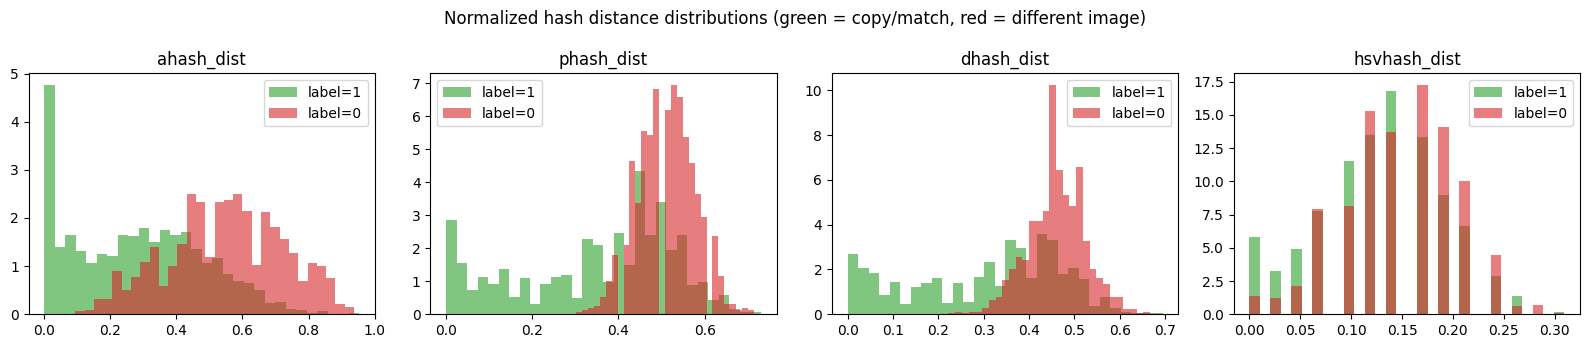

In [ ]:
# Feature distributions by class — sanity check that positives/negatives separate
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=False)
for ax, feat in zip(axes, FEATURES):
    for lbl, color in [(1, "tab:green"), (0, "tab:red")]:
        ax.hist(df.loc[df.label == lbl, feat], bins=30, alpha=0.6,
                color=color, label=f"label={lbl}", density=True)
    ax.set_title(feat)
    ax.legend()
fig.suptitle("Normalized hash distance distributions (green = copy/match, red = different image)")
plt.tight_layout()
plt.show()

## 2. Stratified 80/20 train–test split

We hold out **20%** of the pairs as a test set, stratifying on `label` so the positive rate is preserved in both splits. The model is trained on the 80% split and every reported metric below is computed on the **untouched** 20% test set.

> Earlier versions of this notebook used `GroupKFold` on the source image to prevent augmented variants of the same seed image from leaking across folds. With the dataset now dominated by DISC21 query↔reference pairs (each a distinct image pair), we switch to a simple stratified hold-out for a clean, fast baseline. If you later want to measure generalization to *unseen source images* specifically, reintroduce grouped splitting on a derived `group` key.

In [ ]:
X = df[FEATURES].to_numpy()
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index.to_numpy(),
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train)} pairs  (positive rate = {y_train.mean():.2%})")
print(f"Test : {len(X_test)} pairs  (positive rate = {y_test.mean():.2%})")

Train: 1778 pairs  (positive rate = 48.71%)
Test : 445 pairs  (positive rate = 48.76%)


## 3. Metric helpers

- **ROC-AUC** — primary, threshold-free ranking quality
- **PR-AUC (average precision)** — more informative under class imbalance
- **Recall @ 95% Precision** — the deployment-relevant number: *how many copymints do we catch if we only allow 5% false flags?*

In [ ]:
def recall_at_precision(y_true, y_score, min_precision=0.95):
    """Max recall achievable while keeping precision >= min_precision.
    Returns (recall, threshold). (0.0, None) if precision target is unreachable."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    # precision/recall have len = len(thresholds)+1; drop the last point (no threshold)
    mask = precision[:-1] >= min_precision
    if not mask.any():
        return 0.0, None
    idxs = np.where(mask)[0]
    best = idxs[np.argmax(recall[idxs])]
    return recall[best], thresholds[best]


def make_model():
    """Standardize features, then L2-regularized logistic regression.
    class_weight='balanced' compensates for the negative-heavy label distribution."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000,
                                   class_weight="balanced",
                                   random_state=RANDOM_STATE)),
    ])

## 4. Train on 80%, evaluate on the held-out 20%

Fit the pipeline on the training split, then score the test split. All metrics below are on the test set the model never saw during fitting.

In [ ]:
model = make_model()
model.fit(X_train, y_train)

test_scores = model.predict_proba(X_test)[:, 1]

print("=== Held-out test metrics (20%) ===")
print(f"ROC-AUC : {roc_auc_score(y_test, test_scores):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, test_scores):.4f}")

r95, thr95 = recall_at_precision(y_test, test_scores, min_precision=0.95)
print(f"Recall @ 95% Precision : {r95:.4f}  (score threshold ~ {thr95:.4f})" if thr95 is not None
      else "95% precision not reachable")

y_pred_05 = (test_scores >= 0.5).astype(int)
print(f"F1 @ threshold 0.5     : {f1_score(y_test, y_pred_05):.4f}")

=== Held-out test metrics (20%) ===
ROC-AUC : 0.8429
PR-AUC  : 0.8735
Recall @ 95% Precision : 0.5438  (score threshold ~ 0.6894)
F1 @ threshold 0.5     : 0.7437


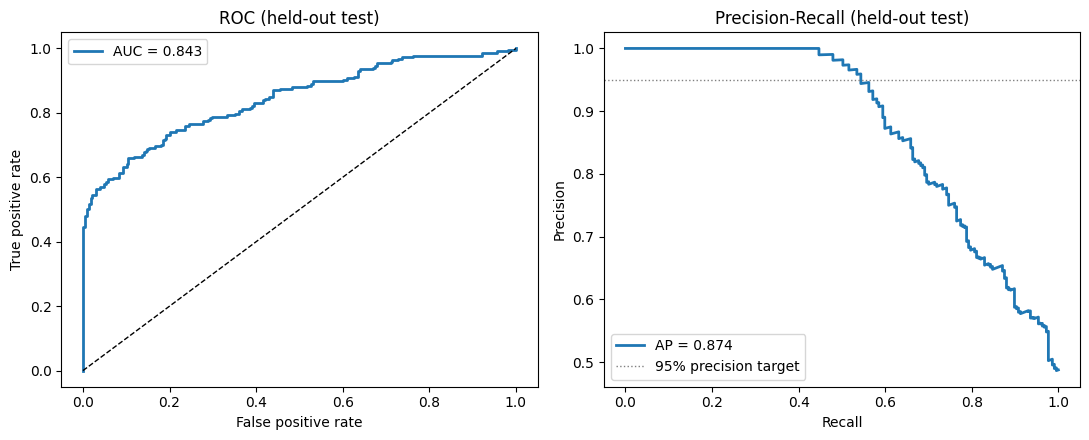

In [ ]:
# ROC and Precision-Recall curves on the held-out test set
fpr, tpr, _ = roc_curve(y_test, test_scores)
prec, rec, _ = precision_recall_curve(y_test, test_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, test_scores):.3f}")
ax1.plot([0, 1], [0, 1], "k--", lw=1)
ax1.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC (held-out test)")
ax1.legend()

ax2.plot(rec, prec, lw=2, label=f"AP = {average_precision_score(y_test, test_scores):.3f}")
ax2.axhline(0.95, color="gray", ls=":", lw=1, label="95% precision target")
ax2.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall (held-out test)")
ax2.legend()

plt.tight_layout()
plt.show()

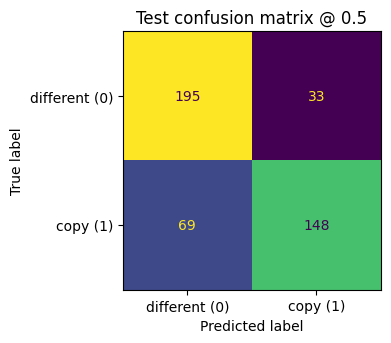

              precision    recall  f1-score   support

   different      0.739     0.855     0.793       228
        copy      0.818     0.682     0.744       217

    accuracy                          0.771       445
   macro avg      0.778     0.769     0.768       445
weighted avg      0.777     0.771     0.769       445



In [ ]:
# Confusion matrix + classification report at threshold 0.5 (test set)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_05),
                       display_labels=["different (0)", "copy (1)"]).plot(ax=ax, colorbar=False)
ax.set_title("Test confusion matrix @ 0.5")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_05, target_names=["different", "copy"], digits=3))

## 5. Error analysis by transformation

Which attack / match types does the model handle well, and where does it break? Mean test-set score per transformation — for `label=1` rows, **higher is better**; for negative types (`cross_image`, `disc21_neg`), **lower is better**.

This is computed on the **held-out test rows only**, so it reflects genuine generalization per transformation (some rare transformations may have very few test rows — check the `count` column).

In [ ]:
test_df = df.loc[idx_test].copy()
test_df["score"] = test_scores

by_tf = (test_df.groupby(["transformation", "label"])["score"]
           .agg(["mean", "min", "max", "count"])
           .reset_index()
           .sort_values(["label", "mean"]))
by_tf

,transformation,label,mean,min,max,count
6,disc21_neg,0,0.2820,0.0272,0.8086,211
3,cross_image,0,0.3740,0.1558,0.6987,17
5,disc21,1,0.6602,0.0246,0.9988,206
2,cropped_30%,1,0.7349,0.7349,0.7349,1
1,cropped_20%,1,0.8394,0.8394,0.8394,1
8,grid_dropout_20%,1,0.9660,0.9660,0.9660,1
4,darkened_0.5x,1,0.9987,0.9984,0.9989,2
7,edge_filter,1,0.9988,0.9988,0.9988,1
11,resized_50%,1,0.9988,0.9988,0.9988,1
10,quality_80%,1,0.9989,0.9988,0.9990,2


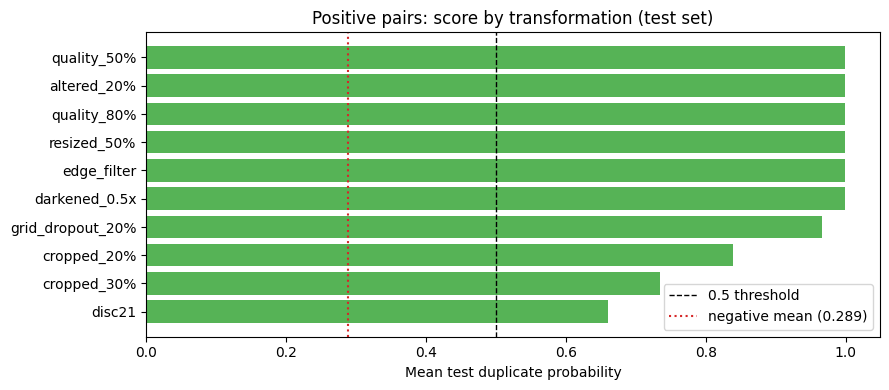

Lowest-scoring TRUE COPIES (missed-detection risk):


,image_b,transformation,score
945,queries/Q75241.jpg,disc21,0.0246
1065,queries/Q86808.jpg,disc21,0.0391
230,queries/Q06231.jpg,disc21,0.0587
824,queries/Q63053.jpg,disc21,0.0761
398,queries/Q21828.jpg,disc21,0.0768
689,queries/Q49418.jpg,disc21,0.1393
528,queries/Q34312.jpg,disc21,0.1508
428,queries/Q25224.jpg,disc21,0.1526


Highest-scoring NON-COPIES (false-flag risk):


,image_a,image_b,transformation,score
1217,references/R038409.jpg,queries/Q92150.jpg,disc21_neg,0.8086
2040,references/R038409.jpg,queries/Q88317.jpg,disc21_neg,0.7899
2165,references/R038409.jpg,queries/Q80665.jpg,disc21_neg,0.7445
2125,references/R038409.jpg,queries/Q05306.jpg,disc21_neg,0.7307
149,images/beach.jpg,images_variants/golden_bridge/covered.png,cross_image,0.6987
1475,references/R038409.jpg,queries/Q88022.jpg,disc21_neg,0.6894
1493,references/R038409.jpg,queries/Q45723.jpg,disc21_neg,0.6867
1266,references/R038409.jpg,queries/Q08488.jpg,disc21_neg,0.6725


In [ ]:
pos = by_tf[by_tf.label == 1].sort_values("mean")
fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(pos))))
ax.barh(pos["transformation"], pos["mean"], color="tab:green", alpha=0.8)
ax.axvline(0.5, color="k", ls="--", lw=1, label="0.5 threshold")
neg_mean = test_df.loc[test_df.label == 0, "score"].mean()
ax.axvline(neg_mean, color="tab:red", ls=":", lw=1.5, label=f"negative mean ({neg_mean:.3f})")
ax.set(xlabel="Mean test duplicate probability", title="Positive pairs: score by transformation (test set)")
ax.legend()
plt.tight_layout()
plt.show()

# Hardest positives & worst negatives on the test set
print("Lowest-scoring TRUE COPIES (missed-detection risk):")
display(test_df[test_df.label == 1].nsmallest(8, "score")[["image_b", "transformation", "score"]])
print("Highest-scoring NON-COPIES (false-flag risk):")
display(test_df[test_df.label == 0].nlargest(8, "score")[["image_a", "image_b", "transformation", "score"]])

## 6. Coefficient interpretation

Coefficients from the model trained on the 80% split, on **standardized features**, so magnitudes are directly comparable: more negative = larger distance pushes harder toward "not a copy".

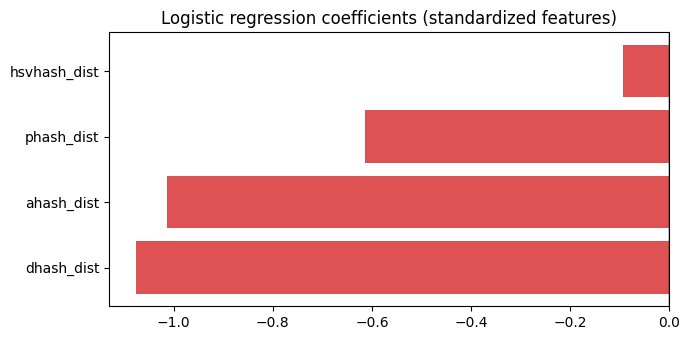

Intercept: 0.4156


,feature,coef (standardized)
2,dhash_dist,-1.0761
0,ahash_dist,-1.0135
1,phash_dist,-0.6142
3,hsvhash_dist,-0.0937


In [ ]:
coef_df = (pd.DataFrame({
    "feature": FEATURES,
    "coef (standardized)": model.named_steps["clf"].coef_[0],
}).sort_values("coef (standardized)"))

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["tab:red" if c < 0 else "tab:blue" for c in coef_df["coef (standardized)"]]
ax.barh(coef_df["feature"], coef_df["coef (standardized)"], color=colors, alpha=0.8)
ax.axvline(0, color="k", lw=1)
ax.set_title("Logistic regression coefficients (standardized features)")
plt.tight_layout()
plt.show()

print(f"Intercept: {model.named_steps['clf'].intercept_[0]:.4f}")
coef_df

## 7. Choosing an operating threshold

For a minting gate, false positives (blocking a legitimate mint) and false negatives (letting a copymint through) have different costs. The table below sweeps thresholds on the **test set**; the **Recall@P95 threshold** from section 4 is the conservative starting point.

In [ ]:
rows = []
for thr in np.arange(0.05, 1.0, 0.05):
    pred = (test_scores >= thr).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    rows.append({"threshold": thr, "precision": precision, "recall": recall,
                 "F1": f1, "flagged": int(tp + fp)})
threshold_table = pd.DataFrame(rows)
threshold_table.style.highlight_max(subset=["F1"], color="#c8e6c9")

,threshold,precision,recall,F1,flagged
0,0.050000,0.493119,0.990783,0.658499,436
1,0.100000,0.514563,0.976959,0.674086,412
2,0.150000,0.556728,0.972350,0.708054,379
3,0.200000,0.577259,0.912442,0.707143,343
4,0.250000,0.632450,0.880184,0.736031,302
5,0.300000,0.664179,0.820276,0.734021,268
6,0.350000,0.709544,0.788018,0.746725,241
7,0.400000,0.737778,0.764977,0.751131,225
8,0.450000,0.780000,0.718894,0.748201,200
9,0.500000,0.817680,0.682028,0.743719,181


## 8. Final model & persistence

Refit on **all** data (train + test) — this is the model you'd serialize for the minting gate. Use the threshold chosen above when wiring it into the gate.

In [ ]:
final_model = make_model()
final_model.fit(X, y)

import joblib
joblib.dump(final_model, "copymint_logreg.joblib")
print("Saved -> copymint_logreg.joblib")

# Inference example (drawn from the held-out test set)
example = test_df.sample(1, random_state=RANDOM_STATE)
p = final_model.predict_proba(example[FEATURES].to_numpy())[0, 1]
print(f"\n{example.iloc[0]['image_a']}  vs  {example.iloc[0]['image_b']}  [{example.iloc[0]['transformation']}]")
print(f"P(duplicate) = {p:.4f}   (true label = {example.iloc[0]['label']})")

Saved -> copymint_logreg.joblib

references/R007235.jpg  vs  queries/Q65559.jpg  [disc21]
P(duplicate) = 0.5071   (true label = 1)


## Next steps

1. **Diversify negatives** — the `disc21_neg` pool leans on a single reference (`R038409`). Build negatives from many distinct references so the boundary reflects general non-matches, not distance-from-one-image. Re-run and compare the held-out numbers.
2. **Cropping is the known weak spot** — `cropped_20/30%` and some `disc21` matches sit near the boundary, consistent with classical hashes lacking crop invariance. This is where the **DINOv2 cosine** feature should be added as a 5th input.
3. **Inpainted positives** — generate inpainted / img2img variants (COCO-Inpaint / SSCD-style) and add them as transformation classes to quantify exactly where the hash-only baseline fails.
4. **Grouped evaluation (optional)** — if you need to prove generalization to *unseen source images*, derive a `group` key (base image of `image_a`) and switch the split to `GroupShuffleSplit` so no source image appears in both train and test.